# Ti Expert vs Universal vs Fine-Tuned OmniXAS Tutorial

This notebook is organized like `OmniXAS_tutorial.ipynb`: load data, train/load one model per section, then evaluate and plot.

If you already trained the models, leave the training flags as `False` and run the notebook top-to-bottom. The model sections will load existing checkpoints.


## 1. Imports and configuration


In [1]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from omnixas.data.ml_data import MLData, MLSplits
from omnixas.model.metrics import ModelMetrics
from omnixas.model.xasblock import XASBlock
from omnixas.model.xasblock_regressor import XASBlockRegressor

torch.set_float32_matmul_precision("high")

# Find repo root even when running this notebook from tutorial_omnixas/.
REPO_ROOT = Path.cwd()
while not ((REPO_ROOT / "pyproject.toml").exists() and (REPO_ROOT / "omnixas").exists()):
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("Could not find OmniXAS repo root.")
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR = REPO_ROOT / "tutorial_omnixas" / "ml_data"
assert DATA_DIR.exists(), f"Missing tutorial ML data: {DATA_DIR}"

OUTPUT_ROOT = REPO_ROOT / "output" / "training"
RESULTS_DIR = OUTPUT_ROOT / "comparisons" / "Ti_expert_universal" / datetime.now().strftime("%Y%m%d_%H%M%S")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_DIM, OUTPUT_DIM = 64, 141
UNIVERSAL_DIMS = [500, 500, 550]
TI_FEFF_EXPERT_DIMS = [600, 600, 450]
TI_VASP_EXPERT_DIMS = [500, 600, 400]

# GPU by default. If CUDA/WSL is broken, diagnose outside Jupyter before changing this.
ACCELERATOR = "gpu"
DEVICES = 1

# Expert/Universal training uses the default paper XASBlock dropout.
# Fine-tuning follows config/training/tunedUnviersalXAS_v1.1.yaml: disable_dropout=true.
DEFAULT_DROPOUT = 0.5
FINETUNE_DROPOUT = 0.0

# Set True only if you want to train/retrain that model.
TRAIN_UNIVERSAL_FEFF = False
TRAIN_TI_FEFF_EXPERT = False
TRAIN_TI_VASP_EXPERT = False
TRAIN_TI_FEFF_TUNED = True
TRAIN_TI_VASP_TUNED = False

CKPT_UNIVERSAL_FEFF = OUTPUT_ROOT / "universalXAS" / "All_FEFF" / "runs"
CKPT_TI_FEFF_EXPERT = OUTPUT_ROOT / "expertXAS" / "Ti_FEFF" / "runs"
CKPT_TI_VASP_EXPERT = OUTPUT_ROOT / "expertXAS" / "Ti_VASP" / "runs"
CKPT_TI_FEFF_TUNED = OUTPUT_ROOT / "tunedUniversalXAS" / "Ti_FEFF" / "runs"
CKPT_TI_VASP_TUNED = OUTPUT_ROOT / "tunedUniversalXAS" / "Ti_VASP" / "runs"

print("Repo root:", REPO_ROOT)
print("Data dir:", DATA_DIR)
print("Results dir:", RESULTS_DIR)


Repo root: /mnt/c/Users/anton/Desktop/OmniXAS
Data dir: /mnt/c/Users/anton/Desktop/OmniXAS/tutorial_omnixas/ml_data
Results dir: /mnt/c/Users/anton/Desktop/OmniXAS/output/training/comparisons/Ti_expert_universal/20260608_093013


## 2. Small utility functions

Only three utilities are used repeatedly: load one split, check for one best checkpoint, and calculate median spectrum MSE.


In [2]:
def load_split(element, spectrum_type):
    data = {}
    for split_name in ["train", "val", "test"]:
        X = np.loadtxt(DATA_DIR / f"{element}_{spectrum_type}_{split_name}_X.txt", dtype=np.float32)
        y = np.loadtxt(DATA_DIR / f"{element}_{spectrum_type}_{split_name}_y.txt", dtype=np.float32)
        assert X.shape[1] == INPUT_DIM and y.shape[1] == OUTPUT_DIM
        data[split_name] = MLData(X=X, y=y)
    return MLSplits(**data)


def val_loss_from_checkpoint(path):
    import re

    match = re.search(r"val_loss[=|_](\d+(?:\.\d+)?)", path.name)
    return float(match.group(1)) if match else float("inf")


def require_best_checkpoint(directory, label):
    """Return a directory containing exactly one best*.ckpt.

    Supports both the old layout:
        .../checkpoints/best*.ckpt
    and the timestamped runs layout:
        .../runs/<timestamp>/best*.ckpt
    """
    directory = Path(directory)
    direct_ckpts = sorted(directory.glob("best*.ckpt"))
    nested_ckpts = sorted(directory.glob("*/best*.ckpt"))

    if direct_ckpts:
        if len(direct_ckpts) > 1:
            raise ValueError(f"Expected one best checkpoint for {label}, found {len(direct_ckpts)}: {direct_ckpts}")
        return directory

    if nested_ckpts:
        best_ckpt = min(nested_ckpts, key=val_loss_from_checkpoint)
        print(f"{label}: selected timestamped run {best_ckpt.parent} ({best_ckpt.name})")
        return best_ckpt.parent

    raise FileNotFoundError(f"Missing {label} checkpoint in {directory}. Train that section first.")


def select_run_directory(runs_dir, label, train_flag):
    runs_dir = Path(runs_dir)
    if train_flag:
        run_dir = runs_dir / datetime.now().strftime("%Y%m%d_%H%M%S")
        run_dir.mkdir(parents=True, exist_ok=False)
        print(f"{label}: training new timestamped run in {run_dir}")
        return run_dir
    return require_best_checkpoint(runs_dir, label)


def median_mse(pred, target):
    return float(np.median(np.mean((target - pred) ** 2, axis=1)))


## 3. Load Ti FEFF and Ti VASP data


In [3]:
ti_feff = load_split("Ti", "FEFF")
ti_vasp = load_split("Ti", "VASP")

print("Ti FEFF train/val/test:", ti_feff.train.X.shape, ti_feff.val.X.shape, ti_feff.test.X.shape)
print("Ti VASP train/val/test:", ti_vasp.train.X.shape, ti_vasp.val.X.shape, ti_vasp.test.X.shape)


Ti FEFF train/val/test: (5140, 64) (641, 64) (641, 64)
Ti VASP train/val/test: (3030, 64) (377, 64) (377, 64)


## 4. Universal FEFF foundation model

This model is trained on all 8 elements.


In [4]:
XASBlock.DROPOUT = DEFAULT_DROPOUT

if TRAIN_UNIVERSAL_FEFF:
    UNIVERSAL_FEFF_DIR = CKPT_UNIVERSAL_FEFF / datetime.now().strftime("%Y%m%d_%H%M%S")
    UNIVERSAL_FEFF_DIR.mkdir(parents=True, exist_ok=False)
    print(f"Training Universal FEFF in timestamped run: {UNIVERSAL_FEFF_DIR}")
else:
    UNIVERSAL_FEFF_DIR = require_best_checkpoint(CKPT_UNIVERSAL_FEFF, "Universal FEFF")

universal_feff_model = XASBlockRegressor(
    directory=str(UNIVERSAL_FEFF_DIR),
    overwrite_save_dir=False,
    input_dim=INPUT_DIM,
    output_dim=OUTPUT_DIM,
    hidden_dims=UNIVERSAL_DIMS,
    batch_size=32,
    max_epochs=1000,
    early_stopping_patience=25,
    initial_lr=1e-2,
    min_lr=1e-4,
    accelerator=ACCELERATOR,
    devices=DEVICES,
)

if TRAIN_UNIVERSAL_FEFF:
    elements = ["Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu"]
    universal_parts = [load_split(el, "FEFF") for el in elements]
    universal_split = MLSplits(
        train=MLData(X=np.concatenate([s.train.X for s in universal_parts]), y=np.concatenate([s.train.y for s in universal_parts])),
        val=MLData(X=np.concatenate([s.val.X for s in universal_parts]), y=np.concatenate([s.val.y for s in universal_parts])),
        test=MLData(X=np.concatenate([s.test.X for s in universal_parts]), y=np.concatenate([s.test.y for s in universal_parts])),
    )
    universal_feff_model.fit(universal_split)

UNIVERSAL_FEFF_DIR = require_best_checkpoint(CKPT_UNIVERSAL_FEFF, "Universal FEFF")
universal_feff_model.cfg.directory = str(UNIVERSAL_FEFF_DIR)
universal_feff_model.load("best")


2026-06-08 09:30:14.690 | INFO     | omnixas.model.xasblock_regressor:load:145 - Loading model from /mnt/c/Users/anton/Desktop/OmniXAS/output/training/universalXAS/All_FEFF/runs/20260602_122112/best-model-epoch=687-val_loss=0.0079.ckpt


Universal FEFF: selected timestamped run /mnt/c/Users/anton/Desktop/OmniXAS/output/training/universalXAS/All_FEFF/runs/20260602_122112 (best-model-epoch=687-val_loss=0.0079.ckpt)
Universal FEFF: selected timestamped run /mnt/c/Users/anton/Desktop/OmniXAS/output/training/universalXAS/All_FEFF/runs/20260602_122112 (best-model-epoch=687-val_loss=0.0079.ckpt)


## 5. Ti FEFF expert model

Trained from scratch on Ti FEFF only, using the Ti FEFF expert architecture from the repo hparams.


In [5]:
XASBlock.DROPOUT = DEFAULT_DROPOUT

TI_FEFF_EXPERT_DIR = select_run_directory(CKPT_TI_FEFF_EXPERT, "Ti FEFF expert", TRAIN_TI_FEFF_EXPERT)

ti_feff_expert_model = XASBlockRegressor(
    directory=str(TI_FEFF_EXPERT_DIR),
    overwrite_save_dir=False,
    input_dim=INPUT_DIM,
    output_dim=OUTPUT_DIM,
    hidden_dims=TI_FEFF_EXPERT_DIMS,
    batch_size=32,
    max_epochs=1000,
    early_stopping_patience=25,
    initial_lr=1e-2,
    min_lr=1e-4,
    accelerator=ACCELERATOR,
    devices=DEVICES,
)

if TRAIN_TI_FEFF_EXPERT:
    ti_feff_expert_model.fit(ti_feff)

TI_FEFF_EXPERT_DIR = require_best_checkpoint(CKPT_TI_FEFF_EXPERT, "Ti FEFF expert")
ti_feff_expert_model.cfg.directory = str(TI_FEFF_EXPERT_DIR)
ti_feff_expert_model.load("best")


2026-06-08 09:30:15.519 | INFO     | omnixas.model.xasblock_regressor:load:145 - Loading model from /mnt/c/Users/anton/Desktop/OmniXAS/output/training/expertXAS/Ti_FEFF/runs/20260603_135300/best-model-epoch=643-val_loss=0.0121.ckpt


Ti FEFF expert: selected timestamped run /mnt/c/Users/anton/Desktop/OmniXAS/output/training/expertXAS/Ti_FEFF/runs/20260603_135300 (best-model-epoch=643-val_loss=0.0121.ckpt)
Ti FEFF expert: selected timestamped run /mnt/c/Users/anton/Desktop/OmniXAS/output/training/expertXAS/Ti_FEFF/runs/20260603_135300 (best-model-epoch=643-val_loss=0.0121.ckpt)


## 6. Ti VASP expert model

Trained from scratch on Ti VASP only.


In [6]:
XASBlock.DROPOUT = DEFAULT_DROPOUT

TI_VASP_EXPERT_DIR = select_run_directory(CKPT_TI_VASP_EXPERT, "Ti VASP expert", TRAIN_TI_VASP_EXPERT)

ti_vasp_expert_model = XASBlockRegressor(
    directory=str(TI_VASP_EXPERT_DIR),
    overwrite_save_dir=False,
    input_dim=INPUT_DIM,
    output_dim=OUTPUT_DIM,
    hidden_dims=TI_VASP_EXPERT_DIMS,
    batch_size=64,
    max_epochs=1000,
    early_stopping_patience=25,
    initial_lr=1e-2,
    min_lr=1e-4,
    accelerator=ACCELERATOR,
    devices=DEVICES,
)

if TRAIN_TI_VASP_EXPERT:
    ti_vasp_expert_model.fit(ti_vasp)

TI_VASP_EXPERT_DIR = require_best_checkpoint(CKPT_TI_VASP_EXPERT, "Ti VASP expert")
ti_vasp_expert_model.cfg.directory = str(TI_VASP_EXPERT_DIR)
ti_vasp_expert_model.load("best")


2026-06-08 09:30:15.653 | INFO     | omnixas.model.xasblock_regressor:load:145 - Loading model from /mnt/c/Users/anton/Desktop/OmniXAS/output/training/expertXAS/Ti_VASP/runs/20260603_142912/best-model-epoch=633-val_loss=0.0500.ckpt


Ti VASP expert: selected timestamped run /mnt/c/Users/anton/Desktop/OmniXAS/output/training/expertXAS/Ti_VASP/runs/20260603_142912 (best-model-epoch=633-val_loss=0.0500.ckpt)
Ti VASP expert: selected timestamped run /mnt/c/Users/anton/Desktop/OmniXAS/output/training/expertXAS/Ti_VASP/runs/20260603_142912 (best-model-epoch=633-val_loss=0.0500.ckpt)


## 7. Fine-tune universal FEFF on Ti FEFF

This loads the universal FEFF weights, changes the save directory, then trains on Ti FEFF.


In [7]:
XASBlock.DROPOUT = FINETUNE_DROPOUT

TI_FEFF_TUNED_DIR = select_run_directory(CKPT_TI_FEFF_TUNED, "Ti FEFF tuned universal", TRAIN_TI_FEFF_TUNED)

ti_feff_tuned_model = XASBlockRegressor(
    directory=str(UNIVERSAL_FEFF_DIR),
    overwrite_save_dir=False,
    input_dim=INPUT_DIM,
    output_dim=OUTPUT_DIM,
    hidden_dims=UNIVERSAL_DIMS,
    batch_size=32,
    max_epochs=1000,
    early_stopping_patience=25,
    initial_lr=1e-2,
    min_lr=1e-4,
    accelerator=ACCELERATOR,
    devices=DEVICES,
)

if TRAIN_TI_FEFF_TUNED:
    ti_feff_tuned_model.load("best")
    ti_feff_tuned_model.cfg.directory = str(TI_FEFF_TUNED_DIR)
    ti_feff_tuned_model.fit(ti_feff)
else:
    ti_feff_tuned_model.cfg.directory = str(TI_FEFF_TUNED_DIR)

TI_FEFF_TUNED_DIR = require_best_checkpoint(CKPT_TI_FEFF_TUNED, "Ti FEFF tuned universal")
ti_feff_tuned_model.cfg.directory = str(TI_FEFF_TUNED_DIR)
ti_feff_tuned_model.load("best")


2026-06-08 09:30:15.747 | INFO     | omnixas.model.xasblock_regressor:load:145 - Loading model from /mnt/c/Users/anton/Desktop/OmniXAS/output/training/universalXAS/All_FEFF/runs/20260602_122112/best-model-epoch=687-val_loss=0.0079.ckpt


Ti FEFF tuned universal: training new timestamped run in /mnt/c/Users/anton/Desktop/OmniXAS/output/training/tunedUniversalXAS/Ti_FEFF/runs/20260608_093015


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/anton/miniconda3/envs/omnixas/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /mnt/c/Users/anton/Desktop/OmniXAS/output/training/tunedUniversalXAS/Ti_FEFF/runs/20260608_093015 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.
/home/anton/miniconda3/envs/omnixas/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

LR finder stopped early after 85 steps due to diverging loss.
Restoring states from the checkpoint path at /mnt/c/Users/anton/Desktop/OmniXAS/output/training/tunedUniversalXAS/Ti_FEFF/runs/20260608_093015/.lr_find_034d5e51-7e48-41a8-9ae9-eab6b32269be.ckpt
Restored all states from the checkpoint at /mnt/c/Users/anton/Desktop/OmniXAS/output/training/tunedUniversalXAS/Ti_FEFF/runs/20260608_093015/.lr_find_034d5e51-7e48-41a8-9ae9-eab6b32269be.ckpt
Learning rate set to 0.00039810717055349724

  | Name  | Type     | Params | Mode  | FLOPs
---------------------------------------------------
0 | loss  | MSELoss  | 0      | train | 0    
1 | model | XASBlock | 639 K  | train | 0    
---------------------------------------------------
639 K     Trainable params
0         Non-trainable params
639 K     Total params
2.557     Total estimated model params size (MB)
16        Modules in train mode
0         Modules in eval mode
0         Total Flops
Restored all states from the checkpoint at /mnt/c/

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

2026-06-08 09:31:19.993 | INFO     | omnixas.model.xasblock_regressor:fit:126 - Best models saved at /mnt/c/Users/anton/Desktop/OmniXAS/output/training/tunedUniversalXAS/Ti_FEFF/runs/20260608_093015/best-model-epoch=13-val_loss=0.0143.ckpt
2026-06-08 09:31:19.994 | INFO     | omnixas.model.xasblock_regressor:fit:127 - Best validation loss: 0.01634504459798336
2026-06-08 09:31:20.106 | INFO     | omnixas.model.xasblock_regressor:load:145 - Loading model from /mnt/c/Users/anton/Desktop/OmniXAS/output/training/tunedUniversalXAS/Ti_FEFF/runs/20260603_143232/best-model-epoch=609-val_loss=0.0121.ckpt


Ti FEFF tuned universal: selected timestamped run /mnt/c/Users/anton/Desktop/OmniXAS/output/training/tunedUniversalXAS/Ti_FEFF/runs/20260603_143232 (best-model-epoch=609-val_loss=0.0121.ckpt)


## 8. Fine-tune universal FEFF on Ti VASP

This is the cross-fidelity case: universal FEFF foundation model → Ti VASP target data.


In [8]:
XASBlock.DROPOUT = FINETUNE_DROPOUT

TI_VASP_TUNED_DIR = select_run_directory(CKPT_TI_VASP_TUNED, "Ti VASP tuned universal", TRAIN_TI_VASP_TUNED)

ti_vasp_tuned_model = XASBlockRegressor(
    directory=str(UNIVERSAL_FEFF_DIR),
    overwrite_save_dir=False,
    input_dim=INPUT_DIM,
    output_dim=OUTPUT_DIM,
    hidden_dims=UNIVERSAL_DIMS,
    batch_size=64,
    max_epochs=1000,
    early_stopping_patience=25,
    initial_lr=1e-2,
    min_lr=1e-4,
    accelerator=ACCELERATOR,
    devices=DEVICES,
)

if TRAIN_TI_VASP_TUNED:
    ti_vasp_tuned_model.load("best")
    ti_vasp_tuned_model.cfg.directory = str(TI_VASP_TUNED_DIR)
    ti_vasp_tuned_model.fit(ti_vasp)
else:
    ti_vasp_tuned_model.cfg.directory = str(TI_VASP_TUNED_DIR)

TI_VASP_TUNED_DIR = require_best_checkpoint(CKPT_TI_VASP_TUNED, "Ti VASP tuned universal")
ti_vasp_tuned_model.cfg.directory = str(TI_VASP_TUNED_DIR)
ti_vasp_tuned_model.load("best")


2026-06-08 09:31:20.466 | INFO     | omnixas.model.xasblock_regressor:load:145 - Loading model from /mnt/c/Users/anton/Desktop/OmniXAS/output/training/tunedUniversalXAS/Ti_VASP/runs/20260603_143956/best-model-epoch=545-val_loss=0.0463.ckpt


Ti VASP tuned universal: selected timestamped run /mnt/c/Users/anton/Desktop/OmniXAS/output/training/tunedUniversalXAS/Ti_VASP/runs/20260603_143956 (best-model-epoch=545-val_loss=0.0463.ckpt)
Ti VASP tuned universal: selected timestamped run /mnt/c/Users/anton/Desktop/OmniXAS/output/training/tunedUniversalXAS/Ti_VASP/runs/20260603_143956 (best-model-epoch=545-val_loss=0.0463.ckpt)


## 9. Evaluate all models

If you already trained all models, you can run from the top through this section without retraining.


In [9]:
comparisons = [
    ("Ti FEFF", "Expert", ti_feff_expert_model, ti_feff),
    ("Ti FEFF", "Universal FEFF", universal_feff_model, ti_feff),
    ("Ti FEFF", "Tuned universal", ti_feff_tuned_model, ti_feff),
    ("Ti VASP", "Expert", ti_vasp_expert_model, ti_vasp),
    ("Ti VASP", "Universal FEFF direct", universal_feff_model, ti_vasp),
    ("Ti VASP", "Tuned universal", ti_vasp_tuned_model, ti_vasp),
]

rows, eval_cache = [], {}
for dataset, model_name, model, split in comparisons:
    pred = model.predict(split.test.X)
    target = split.test.y
    metrics = ModelMetrics(predictions=pred, targets=target)
    baseline = np.repeat(split.train.y.mean(axis=0, keepdims=True), len(target), axis=0)
    baseline_median = median_mse(baseline, target)

    eval_cache[(dataset, model_name)] = {"predictions": pred, "targets": target}
    rows.append({
        "dataset": dataset,
        "model": model_name,
        "mse": float(metrics.mse),
        "median_mse": float(metrics.median_of_mse_per_spectra),
        "baseline_median_mse": baseline_median,
        "eta": baseline_median / metrics.median_of_mse_per_spectra,
    })

results = pd.DataFrame(rows)
display(results)
results.to_csv(RESULTS_DIR / "ti_model_comparison.csv", index=False)
print("Saved:", RESULTS_DIR / "ti_model_comparison.csv")


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/anton/miniconda3/envs/omnixas/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to 

,dataset,model,mse,median_mse,baseline_median_mse,eta
0,Ti FEFF,Expert,0.011969,0.006866,0.048614,7.080321
1,Ti FEFF,Universal FEFF,0.014905,0.010238,0.048614,4.748402
2,Ti FEFF,Tuned universal,0.011967,0.007303,0.048614,6.656502
3,Ti VASP,Expert,0.054786,0.033744,0.170714,5.059071
4,Ti VASP,Universal FEFF direct,0.180366,0.165950,0.170714,1.028709
5,Ti VASP,Tuned universal,0.052609,0.032671,0.170714,5.225176


Saved: /mnt/c/Users/anton/Desktop/OmniXAS/output/training/comparisons/Ti_expert_universal/20260608_093013/ti_model_comparison.csv


## 10. Metric bar plots


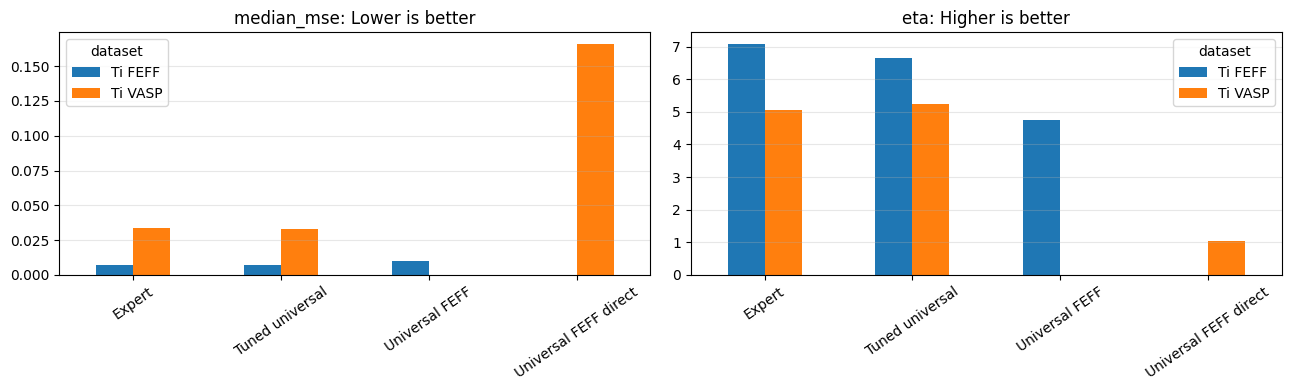

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, title in [
    (axes[0], "median_mse", "Lower is better"),
    (axes[1], "eta", "Higher is better"),
]:
    pivot = results.pivot(index="model", columns="dataset", values=metric)
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"{metric}: {title}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "metric_bars.png", dpi=200)
plt.show()


## 11. Spectrum overlay plots


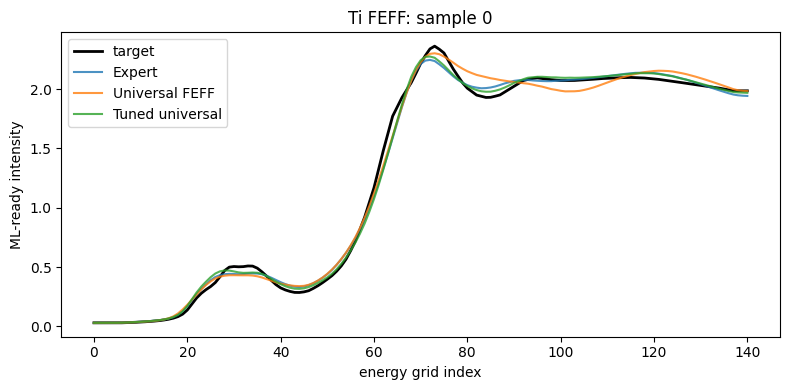

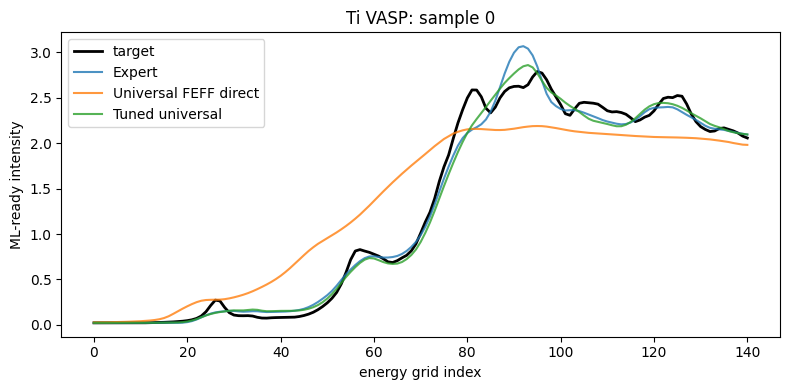

In [11]:
sample_index = 0
for dataset in results["dataset"].unique():
    plt.figure(figsize=(8, 4))
    first_key = next(k for k in eval_cache if k[0] == dataset)
    plt.plot(eval_cache[first_key]["targets"][sample_index], color="black", linewidth=2, label="target")
    for key, result in eval_cache.items():
        if key[0] == dataset:
            plt.plot(result["predictions"][sample_index], label=key[1], alpha=0.8)
    plt.title(f"{dataset}: sample {sample_index}")
    plt.xlabel("energy grid index")
    plt.ylabel("ML-ready intensity")
    plt.legend()
    plt.tight_layout()
    out = RESULTS_DIR / f"{dataset.replace(' ', '_')}_sample_overlay.png"
    plt.savefig(out, dpi=200)
    plt.show()
